In [119]:
import pandas as pd


df1 = pd.read_csv("C:\\Dane\\Projekt_PDU\\202502-citibike-tripdata_3.csv")
df2 = pd.read_csv("C:\\Dane\\Projekt_PDU\\202502-citibike-tripdata_1.csv")
df3 = pd.read_csv("C:\\Dane\\Projekt_PDU\\202502-citibike-tripdata_2.csv")
df = pd.concat((df1,df2,df3),ignore_index=True)
print(df.head())
print(df.shape)


C:\Users\kacpe\AppData\Local\Temp\ipykernel_28384\2681736134.py:5: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("C:\\Dane\\Projekt_PDU\\202502-citibike-tripdata_1.csv")
C:\Users\kacpe\AppData\Local\Temp\ipykernel_28384\2681736134.py:6: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("C:\\Dane\\Projekt_PDU\\202502-citibike-tripdata_2.csv")


            ride_id  rideable_type               started_at  \
0  6AD8AA6957718325   classic_bike  2025-02-28 15:20:51.021   
1  5BB04C2CEFA8A102  electric_bike  2025-02-17 10:10:37.715   
2  AFD4A963A22D88F8   classic_bike  2025-02-25 16:17:32.232   
3  88D574957422333E  electric_bike  2025-02-28 18:03:33.721   
4  0C5D956527417445  electric_bike  2025-02-23 18:14:37.859   

                  ended_at              start_station_name start_station_id  \
0  2025-02-28 15:25:52.490             Murray St & West St          5329.08   
1  2025-02-17 10:19:50.960              Park Ave & E 41 St          6432.08   
2  2025-02-25 16:21:53.863  Metropolitan Ave & Bedford Ave          5308.04   
3  2025-02-28 18:14:15.107                 1 Ave & E 18 St          5854.09   
4  2025-02-23 18:19:17.358              Park Ave & E 41 St          6432.08   

                end_station_name end_station_id  start_lat  start_lng  \
0         Liberty St & Nassau St        5105.09  40.715030 -74.012460   


In [120]:
print(df.dtypes)
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])
print(df.dtypes)

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id       object
end_station_name          str
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object
ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id              object
end_station_name                 str
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object


In [121]:
df["hour"] = df["started_at"].dt.hour
df["weekday"] = df["started_at"].dt.day_name()
print(df.head())

            ride_id  rideable_type              started_at  \
0  6AD8AA6957718325   classic_bike 2025-02-28 15:20:51.021   
1  5BB04C2CEFA8A102  electric_bike 2025-02-17 10:10:37.715   
2  AFD4A963A22D88F8   classic_bike 2025-02-25 16:17:32.232   
3  88D574957422333E  electric_bike 2025-02-28 18:03:33.721   
4  0C5D956527417445  electric_bike 2025-02-23 18:14:37.859   

                 ended_at              start_station_name start_station_id  \
0 2025-02-28 15:25:52.490             Murray St & West St          5329.08   
1 2025-02-17 10:19:50.960              Park Ave & E 41 St          6432.08   
2 2025-02-25 16:21:53.863  Metropolitan Ave & Bedford Ave          5308.04   
3 2025-02-28 18:14:15.107                 1 Ave & E 18 St          5854.09   
4 2025-02-23 18:19:17.358              Park Ave & E 41 St          6432.08   

                end_station_name end_station_id  start_lat  start_lng  \
0         Liberty St & Nassau St        5105.09  40.715030 -74.012460   
1           

In [122]:
helper = (df["started_at"].dt.hour*60 + df["started_at"].dt.minute)
df["5minute"] = helper - helper%5 - 14*60
#Odejmujemy 14*60, żeby zaczynać odliczanie od godziny 16

In [123]:
df_day = df.loc[df["started_at"].dt.date == pd.to_datetime("2025-02-09").date(),:]
df_rest = df.loc[df["started_at"].dt.date != pd.to_datetime("2025-02-09").date(),:]
df_rest = df_rest.loc[df["weekday"] == "Sunday",:]
print(df_rest.head())

             ride_id  rideable_type              started_at  \
4   0C5D956527417445  electric_bike 2025-02-23 18:14:37.859   
5   A5EFBE4DE3BAAAF3   classic_bike 2025-02-16 17:35:42.524   
6   4C562BD610BFE26D   classic_bike 2025-02-23 16:14:46.902   
8   71B3F74C6153EF44  electric_bike 2025-02-16 07:33:10.152   
15  FDC4DFDF103946C6  electric_bike 2025-02-23 06:41:19.560   

                  ended_at    start_station_name start_station_id  \
4  2025-02-23 18:19:17.358    Park Ave & E 41 St          6432.08   
5  2025-02-16 17:47:34.541      12 Ave & W 40 St          6765.01   
6  2025-02-23 16:17:32.998   N 7 St & Driggs Ave          5340.01   
8  2025-02-16 07:39:33.967  Clinton St & 4 Place          4119.04   
15 2025-02-23 06:44:30.740       E 13 St & 2 Ave          5820.08   

                 end_station_name end_station_id  start_lat  start_lng  \
4                 5 Ave & E 30 St        6248.08  40.751581 -73.977910   
5   Washington St & Gansevoort St        6039.06  40.76087

In [124]:
#Grupujemy df_day po 5minute
df_day = df_day.loc[df_day.hour >= 14,:]
df_day = df_day.groupby("5minute")
df_day_grouped = df_day["ride_id"].count().reset_index()
df_rest = df_rest.loc[df_rest.hour >= 14,:]
df_rest = df_rest.groupby("5minute")
df_rest_grouped = df_rest["ride_id"].count().reset_index()
df_rest_grouped["ride_id"] = df_rest_grouped["ride_id"]//2
print(df_day_grouped.head())
print(df_rest_grouped.head())
#Mamy już gotową 1szą tabelkę na wykres

   5minute  ride_id
0        0      213
1        5      211
2       10      202
3       15      198
4       20      223
   5minute  ride_id
0        0      541
1        5      500
2       10      519
3       15      526
4       20      535


In [126]:
print(df_day_grouped.dtypes)
print(df_rest_grouped.dtypes)

5minute    int32
ride_id    int64
dtype: object
5minute    int32
ride_id    int64
dtype: object


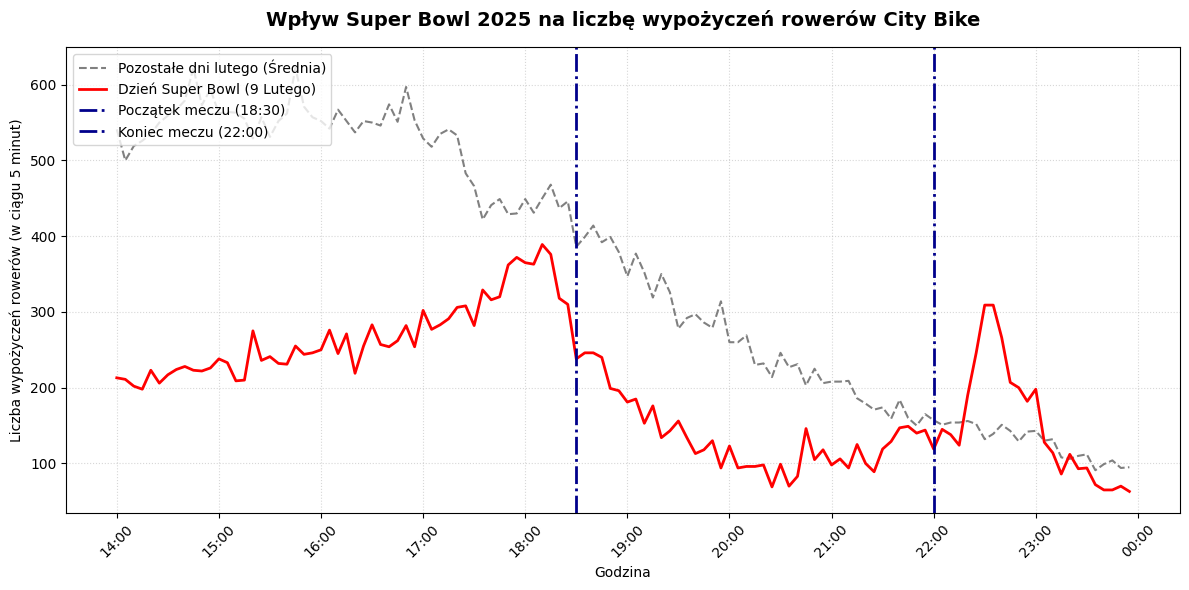

In [134]:
import matplotlib.pyplot as plt

# 1. Tworzenie czystego wykresu (szeroki, czytelny)
plt.figure(figsize=(12, 6))

# 2. Rysowanie linii bazowej dla pozostałych dni lutego (szara, przerywana)
plt.plot(
    df_rest_grouped["5minute"],
    df_rest_grouped["ride_id"],
    color="gray",
    linestyle="--",
    label="Pozostałe dni lutego (Średnia)",
)


# 4. Rysowanie linii dla dnia Super Bowl (czerwona, grubsza)
plt.plot(
    df_day_grouped["5minute"],
    df_day_grouped["ride_id"],
    color="red",
    linewidth=2,
    label="Dzień Super Bowl (9 Lutego)",
)
# Linia dla 18:30 (X = 270)
plt.axvline(
    x=270,
    color="darkblue",
    linestyle="-.",  # Kropka-kreska, żeby ładnie wyróżniała się od innych linii
    linewidth=2,
    label="Początek meczu (18:30)",
)

# Linia dla 22:00 (X = 480)
plt.axvline(
    x=480,
    color="darkblue",
    linestyle="-.",
    linewidth=2,
    label="Koniec meczu (22:00)",
)
# 5. Przerabianie indeksowania osi X na ludzkie godziny (od 14:00 do 00:00)
# Krok co 60 minut od punktu startowego 14:00 (który ma wartość minutową w Twoich danych)
# UWAGA: Zakładam, że Twoja kolumna '5minute' dla godziny 14:00 zaczyna się od wartości 840 (14*60)
# Jeśli zaczyna się od 0, zmień tablicę punkty_x na: [0, 60, 120, 180, 240, 300, 360, 420, 480, 540, 600]
punkty_x = [0, 60, 120, 180, 240, 300, 360, 420, 480, 540, 600]
godziny_etykiety = [
    "14:00",
    "15:00",
    "16:00",
    "17:00",
    "18:00",
    "19:00",
    "20:00",
    "21:00",
    "22:00",
    "23:00",
    "00:00",
]
plt.xticks(punkty_x, godziny_etykiety, rotation=45)

# 6. Dodanie tytułu i opisów osi
plt.title(
    "Wpływ Super Bowl 2025 na liczbę wypożyczeń rowerów City Bike",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Godzina")
plt.ylabel("Liczba wypożyczeń rowerów (w ciągu 5 minut)")

# 7. Siatka w tle, legenda i wyświetlenie
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()